In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from pathlib import Path
import sys

import cogwheel.likelihood
import cogwheel.data
import gwosc
import gwpy.table

sys.path.insert(0, '../code')
import make_event_data
from parameter_estimation import get_chirp_mass, get_table_data, check_eventname

In [3]:
# get a list of events for which to make event data
catalog = 'GWTC-4.0'

# look for events in this directory
catalog_dir = f'/home/javier.roulet/cogwheel-catalog/raw_data/{catalog}'

event_dir_list = glob.glob(f'{catalog_dir}/GW*')
eventname_list = [
    event_dir.split('/')[-1] for event_dir in event_dir_list
]
print(f"found {len(eventname_list)} events")

found 129 events


In [28]:
# select a subset of all the events in the catalog, for which to make .npz files
event_tables = gwpy.table.EventTable.fetch_open_data(catalog, selection='network_matched_filter_snr > 14')
# find the subset of these with SNR < 15 (since we've already processed the events with SNR > 15)
subset_idx = (event_tables['network_matched_filter_snr'] < 15)
event_table_subset = event_tables[subset_idx]
eventname_list_subset = []
for name in eventname_list:
    if name in ''.join(event_table_subset['name']):
        eventname_list_subset.append(name)

In [29]:
len(eventname_list_subset)

2

In [31]:
# for some reason, GW240105_151143 has very little table data, including the redshift (None), so remove this for now
events_to_pop = ['GW240105_151143']
for event in events_to_pop:
    if event in eventname_list_subset:
        eventname_list_subset.pop(np.where(np.array(eventname_list_subset) == event)[0][0])

In [32]:
eventname_list_subset

['GW230518_125908', 'GW240104_164932']

In [41]:
# pick an event from the subset
eventname = eventname_list_subset[1]
print(eventname)
# get the corresponding event path
eventpath = os.path.join(catalog_dir, eventname)
assert os.path.exists(eventpath), f"eventpath ({eventpath}) does not exist!"
# and get the corresponding event table
idx = [eventname == x.split('-')[0] for x in event_tables['name']]
event_table = event_tables[idx]
assert len(event_table) == 1, f"{len(event_table)} events found for {eventname} in the table"

GW240104_164932


In [42]:
# do we have a config for this event?
config_fn = os.path.join('/home/javier.roulet/cogwheel-catalog/processed_data', catalog, eventname, 'event_data_kwargs.json')
if os.path.exists(config_fn):
    with open(config_fn) as file:
        event_pars = json.load(file)
else:
    event_pars = {}

found 1 files for GW240104_164932 (GWTC-4.0) in detectors H


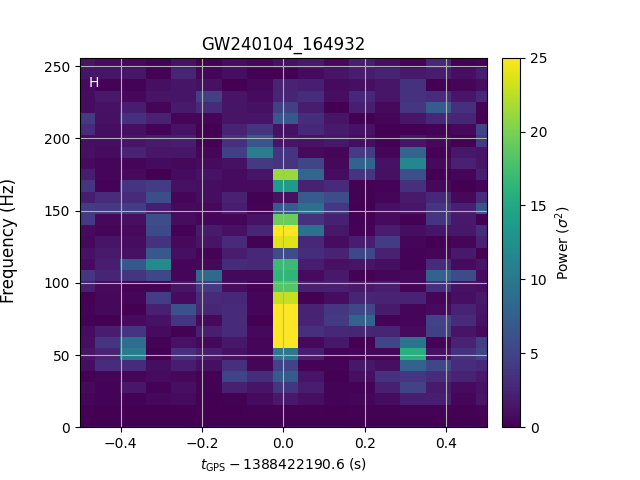

got chirp mass as 42.93 Msun
Searching incoherent solution for GW240104_164932
Set intrinsic parameters, lnL = 103.91798725202409
Set time, lnL(H) = 103.92067764050226
Set sky location, lnL = 103.92067764050235
Set phase and distance, lnL = 103.92067764050235
Set mchirp_range = (np.float64(21.835579112101982), np.float64(151.93513819775484))


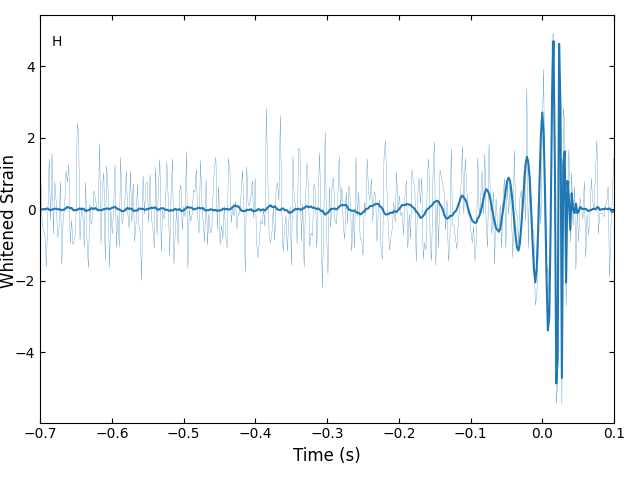

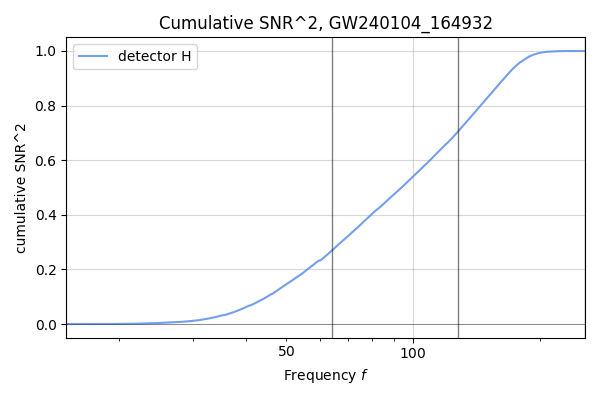

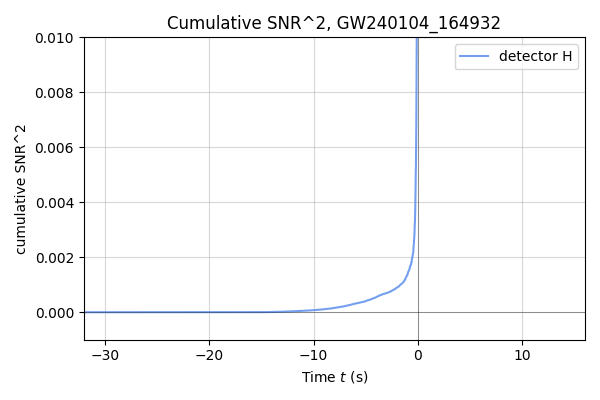

In [44]:
## CHOOSE EVENT CONFIGS ##

# kwargs for processing the event data: this is what we're testing, to save as the config if we're happy with it!
kwargs = dict(
    fmax = 256,
    wht_filter_duration = 32,
    t_before = 32,
    t_after = 16
)

filenames = sorted(Path(eventpath).glob('*.hdf5'))
assert eventname == Path(eventpath).name
detector_names = ''.join(filename.name[0] for filename in filenames)
print(f"found {len(filenames)} files for {eventname} ({catalog}) in detectors {detector_names}")
tgps = gwosc.datasets.event_gps(eventname)

event_data = cogwheel.data.EventData.from_timeseries(
    filenames, eventname, detector_names, tgps, **kwargs)

# check out the spectrogram
event_data.specgram(nfft=512)
event_data.specgram(np.multiply(kwargs.get('wht_filter_duration', 32), (-.5, .5)))
event_data.specgram((-.5, .5))
plt.show()

# get the chirp mass "guess" (from the published result)
try:
    mchirp_guess = get_chirp_mass(event_table)
except Exception as e:
    print(e)
    print("event table:")
    print(event_table)
print(f"got chirp mass as {mchirp_guess:.2f} Msun")

# compute the posterior at the max likelihood
post = cogwheel.posterior.Posterior.from_event(event_data, mchirp_guess, 'IMRPhenomXAS', 'IASPrior')
post.likelihood.plot_whitened_wf(post.likelihood.par_dic_0)
plt.show()
post.likelihood.asd_drift, post.likelihood.lnlike(post.likelihood.par_dic_0)

# cumulative SNR^2 for each detector
wht_amp = np.abs(post.likelihood._get_h_f(post.likelihood.par_dic_0)
                 * event_data.wht_filter)
cumsnr2 = np.cumsum(wht_amp**2, axis=-1)
cumsnr2 /= cumsnr2[:, [-1]]

# colorsss
cs = ['cornflowerblue', 'mediumseagreen', 'coral']

# plot
fig, ax = plt.subplots(figsize=(6,4), tight_layout=True)
for i, cumsnr2_ in enumerate(cumsnr2):
    ax.semilogx(event_data.frequencies, cumsnr2_, label=f'detector {list(detector_names)[i]}', c=cs[i], alpha=0.9)
ax.set_xlim(event_data.fbounds)
ax.set_xlabel('Frequency $f$')
ax.set_ylabel('cumulative SNR^2')
ax.axhline(0., c='k', lw=0.5, alpha=0.5)
ax.grid(alpha=0.5)
for f in [64, 128, 256, 512, 1024]:
    ax.axvline(f, c='k', alpha=0.5, lw=1)
ax.set_title(f'Cumulative SNR^2, {eventname}')
ax.legend()
plt.show()

# same thing but in the time domain
wht_amp_td = np.abs(np.fft.irfft(post.likelihood._get_h_f(post.likelihood.par_dic_0)
                                 * event_data.wht_filter))
cumsnr2 = np.cumsum(wht_amp_td**2, axis=-1)
cumsnr2 /= cumsnr2[:, [-1]]

# plot
fig, ax = plt.subplots(figsize=(6,4), tight_layout=True)
for i, cumsnr2_ in enumerate(cumsnr2):
    ax.plot(event_data.times - event_data.tcoarse, cumsnr2_, label=f'detector {list(detector_names)[i]}', c=cs[i], alpha=0.9)
ax.set_xlabel('Time $t$ (s)')
ax.set_ylabel('cumulative SNR^2')
ax.set_xlim(-kwargs['t_before'], kwargs['t_after'])
ax.set_ylim(-.001, 0.01)
ax.axhline(0., c='k', lw=0.5, alpha=0.5)
ax.axvline(0., c='k', lw=0.5, alpha=0.5)
ax.grid(alpha=0.5)
ax.set_title(f'Cumulative SNR^2, {eventname}')
ax.legend()
plt.show()

In [45]:
# once we're satisfied with the event configs, we can make the processed event data:
make_event_data.make_event_data(
    overwrite=True,
    eventname=eventname,
    catalog=catalog,
    event_data_kwargs=kwargs,
    tgps=None,
    inpaint_times_by_det=None,
    plot=True,
)

Created event_data in /home/javier.roulet/cogwheel-catalog/processed_data/GWTC-4.0/GW240104_164932


EventData(GW240104_164932)

# Overwrite existing EventData if needed

In [9]:
output_dir = Path(os.path.join('/home/javier.roulet/cogwheel-catalog/processed_data', catalog, eventname))
event_data = cogwheel.data.EventData.from_npz(filename=output_dir/f'{eventname}.npz')

In [10]:
def suggest_inpaint_times(self, xlim=None, nfft=64, noverlap=None, vmax=20.,
                          exclude=(-0.5, 0.1)):
    noverlap = noverlap or nfft // 2

    f_sampling = 2 * self.fbounds[1]

    norm = plt.Normalize(0, vmax)
    fig, axes = plt.subplots(len(self.detector_names),
                             sharex=True, sharey=True,
                             gridspec_kw={'hspace': .1},
                             squeeze=False)
    axes = axes[:, 0]

    inpaint_times_by_det = {}
    for i, ax in enumerate(axes):
        wht_data_td = (np.fft.irfft(self.strain[i] * self.wht_filter[i])
                       * np.sqrt(2 * f_sampling))
        spectrum, _, t, _ = ax.specgram(
            wht_data_td * np.sqrt(f_sampling),
            NFFT=nfft, noverlap=noverlap, Fs=f_sampling,
            xextent=(self.times[[0, -1]] - self.tcoarse),
            scale='linear', norm=norm)
        t -= self.tcoarse  # Put event at t=0

        ax.grid()
        ax.text(.02, .95, self.detector_names[i], ha='left', va='top',
                transform=ax.transAxes, c='w')

        clean = ((spectrum.max(axis=0) < vmax)
                 | ((t > exclude[0]) & (t < exclude[1])))
        segments = t[cogwheel.likelihood.likelihood.hole_edges(clean)]
        for segment in segments:
            ax.axvspan(*segment, color='r', ymax=.025)

        inpaint_times_by_det[str(self.detector_names[i])] = segments.tolist()
    axes[0].set_title('Original')

    # Show how would it look
    self.inpaint(inpaint_times_by_det).specgram()
    plt.gcf().axes[0].set_title('Inpainted')

    return inpaint_times_by_det
    

In [11]:
suggested_inpaint_times = suggest_inpaint_times(event_data, vmax=20, nfft=256)

AttributeError: 'EventData' object has no attribute 'inpaint'

In [12]:
dir(event_data)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_check_wht_filter_validity',
 '_get_f_strain_whtfilter_from_timeseries',
 '_read_timeseries',
 '_set_strain',
 'blued_strain',
 'detector_names',
 'df',
 'eventname',
 'fbounds',
 'frequencies',
 'from_npz',
 'from_timeseries',
 'fslice',
 'gaussian_noise',
 'get_filename',
 'get_init_dict',
 'get_whitened_td',
 'inject_signal',
 'injection',
 'nfft',
 'reinstantiate',
 'specgram',
 'strain',
 'tcoarse',
 'tgps',
 'times',
 'to_json',
 'to_npz',
 'wht_filter']

In [75]:
# Edit manually if desired
suggested_inpaint_times

{'H': [[-23.25, -23.1875],
  [-22.375, -22.3125],
  [-18.4375, -18.375],
  [-18.3125, -18.25],
  [-15.75, -15.6875],
  [-3.1875, -3.125],
  [1.25, 1.3125],
  [3.3125, 3.375],
  [3.625, 3.6875],
  [7.5625, 7.625],
  [7.6875, 7.75],
  [11.0625, 11.125],
  [13.625, 13.6875]],
 'L': [[-11.6875, -11.625],
  [-7.75, -7.6875],
  [-1.5625, -1.5],
  [11.25, 11.5625]]}

Once satisfied, append inpaint times and resubmit

In [76]:
# Load preexisting inpaint times (if any)
try:
    with open(output_dir / 'inpaint_times_by_det.json') as file:
        inpaint_times_by_det = json.load(file)
except FileNotFoundError:
    inpaint_times_by_det = {}

# Append new ones
for k, v in suggested_inpaint_times.items():
    inpaint_times_by_det[k] = inpaint_times_by_det.get(k, []) + v

In [77]:
inpaint_times_by_det

{'H': [[-22.359375, -22.34375],
  [-18.84375, -18.828125],
  [-18.40625, -18.390625],
  [-18.28125, -18.265625],
  [-12.96875, -12.953125],
  [-8.921875, -8.90625],
  [1.5, 1.515625],
  [3.21875, 3.234375],
  [3.3125, 3.328125],
  [3.640625, 3.65625],
  [7.546875, 7.578125],
  [7.6875, 7.703125],
  [10.25, 10.265625],
  [13.625, 13.640625],
  [18.046875, 18.0625],
  [-23.25, -23.1875],
  [-22.375, -22.3125],
  [-18.4375, -18.375],
  [-18.3125, -18.25],
  [-15.75, -15.6875],
  [-3.1875, -3.125],
  [1.25, 1.3125],
  [3.3125, 3.375],
  [3.625, 3.6875],
  [7.5625, 7.625],
  [7.6875, 7.75],
  [11.0625, 11.125],
  [13.625, 13.6875]],
 'L': [[-3.59375, -3.578125],
  [3.265625, 3.28125],
  [11.34375, 11.359375],
  [11.40625, 11.421875],
  [11.4375, 11.453125],
  [11.5, 11.515625],
  [-11.6875, -11.625],
  [-7.75, -7.6875],
  [-1.5625, -1.5],
  [11.25, 11.5625]]}

Created event_data in /home/javier.roulet/cogwheel-catalog/processed_data/GWTC-4.0/GW231226_101520


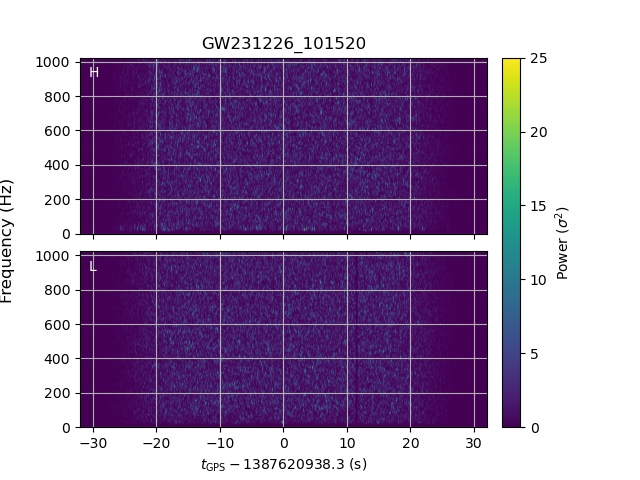

In [78]:
ed = make_event_data.make_event_data(
    overwrite=True,
    eventname=eventname,
    catalog=catalog,
    event_data_kwargs=None,
    tgps=None,
    inpaint_times_by_det=inpaint_times_by_det,
    plot=True,
)

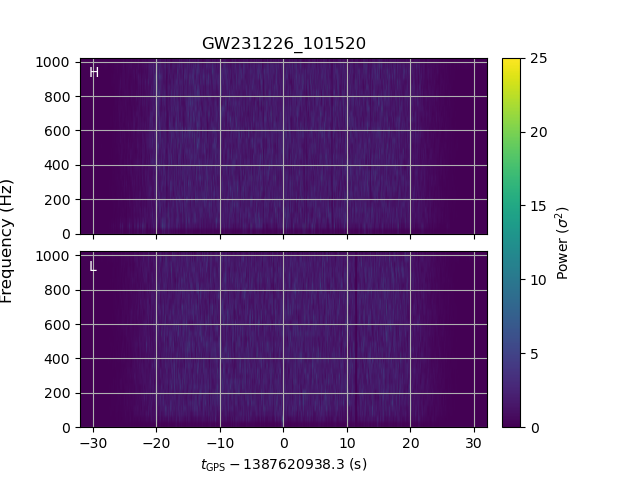

In [79]:
ed.specgram()